# Thameswood Distillers — Iowa target accounts

**V1.** The 25 accounts from Thameswood's own CRM they should approach next, ranked by what
third-party Iowa market data proves about each one, with the reasoning behind the order.

---

### The headline

- **85** accounts are approachable: every account in the CRM except the 15 already Closed Won.
- **Only 6 of them clear the evidence bar.** Six accounts buy premium-tier gin at meaningful
  volume. Ranks 7–25 are filled by gin buyers whose premium volume is negligible — the client's
  book does not contain 25 strong candidates, and section 2 shows why.
- **47 of the 85 cannot be matched to the market data at all** — 40 carry no `store_number`.
  That is the single highest-value thing the client could fix, and it is section 6.
- **The category is not dying — it is premiumising.** Premium-tier gin dollars are flat since
  2021 while the value tier fell 21%, and premium spend *per stocking store* is up 24%
  (section 4). This corrects an earlier read of this data that said the opposite.

### How to read this

Section 1 is the deliverable. Sections 2–6 are the argument for it. Section 7 is what we assumed,
what we would ask the client, and where this version is weak.

### Where the numbers come from

Every figure below is computed in **dbt** and read out of BigQuery. This notebook contains **no
ranking logic** — it queries, formats and plots. That is deliberate: two places that compute the
same number eventually disagree, and the warehouse is the one that is version-controlled and
tested (65 data tests pass on the current build).

```
raw_crm.*   ─┐
             ├─ stg_* (clean/type) ─ int_* (current state, pivot) ─ mart_target_accounts
raw_iowa.*  ─┘                                                       (85 rows, 1 per account)
```

**Scope decision:** the universe is the client's CRM. Iowa stores that are *not* in the CRM are
out of scope for this version — the market data scores accounts, it does not supply them.

In [1]:
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from google.cloud import bigquery

PROJECT = os.environ.get("BQ_PROJECT_ID", "gin-accounts-recommendation")
client = bigquery.Client(project=PROJECT, location="US")

# Palette and chart chrome. Single source so every figure below matches.
# Validated with the dataviz palette checker against surface #fcfcfb:
# worst adjacent CVD dE 9.2 (deutan), normal-vision dE 27.6, all checks pass.
# AQUA sits below 3:1 contrast, so every series it is used on is direct-labelled.
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#d5d4cd"

mpl.rcParams.update({
    # Off, and it is not cosmetic: matplotlib reads $...$ as LaTeX mathtext, so
    # a label like "$25.41 ($27.6M of purchases)" silently renders in italic
    # math with BOTH dollar signs eaten. Every currency label on this page
    # depends on this line.
    "text.parse_math": False,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "figure.dpi": 130,
})

targets = client.query(f"""
    select * from `{PROJECT}.analytics.mart_target_accounts` order by target_rank
""").to_dataframe()

# The whole gin market, by Iowa's own category names. Underpins section 3.
categories = client.query(f"""
    select gin_category, any_value(cat_group) as cat_group,
           sum(net_sale_dollars) as dollars, sum(net_bottles) as bottles
    from `{PROJECT}.analytics.stg_iowa__store_category_yearly`
    where gin_category is not null
    group by gin_category
""").to_dataframe()
categories["usd_per_bottle"] = categories["dollars"] / categories["bottles"]

# Five full calendar years. 2026 is excluded on purpose -- the data ends 30 Apr
# 2026, so it holds four months against everyone else's twelve.
trend = client.query(f"""
    select year, cat_group,
           sum(net_sale_dollars) as dollars,
           count(distinct store_number) as stores
    from `{PROJECT}.analytics.stg_iowa__store_category_yearly`
    where cat_group != 'NON_GIN' and year between 2021 and 2025
    group by year, cat_group order by year, cat_group
""").to_dataframe()

def usd(v):
    """Currency, NaN-safe -- market columns are NULL for unmatched accounts."""
    return "-" if pd.isna(v) else f"${v:,.0f}"

def gbp(v):
    return "-" if pd.isna(v) else f"£{v:,.0f}"

print(f"{len(targets):,} approachable accounts loaded from {PROJECT}.analytics.mart_target_accounts")
print(f"as of CRM snapshot {targets['crm_as_of_date'].max()}")

/Users/jeanchacon/Documents/codes/interviews/alchemia-labs-tech-assessment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/jeanchacon/Documents/codes/interviews/alchemia-labs-tech-assessment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


85 approachable accounts loaded from gin-accounts-recommendation.analytics.mart_target_accounts
as of CRM snapshot 2026-05-02


## 1. The list

The 25 accounts to approach next. **Tier** is what the Iowa market data proves about the account
(section 2 explains the ladder). **Gin $** is the measure that decided the position *within* that
tier. **prem %** is what share of the account's gin spend is premium-tier — the fit signal.

Every one of the 85 accounts has a named contact, so each row below is directly callable.

In [2]:
top = targets[targets["is_top_target"]].copy()

view = pd.DataFrame({
    "#": top["target_rank"],
    "T": top["evidence_tier"],
    "Account": top["account_name"].str.slice(0, 32),
    "City": top["city"].str.title(),
    "Gin $": top["tier_measure"].map(usd),
    "prem %": (top["premium_share_of_gin"].fillna(0) * 100).round(0).astype(int).astype(str) + "%",
    "Segment": top["crm_segment"],
    "Owner": top["account_owner"],
    "Contact": top["contact_name"],
    "Pipeline": top["open_pipeline_gbp"].map(gbp),
}).set_index("#")

display(view)

print("T = evidence tier:")
for t, label in targets.groupby("evidence_tier")["evidence_tier_label"].first().items():
    print(f"  {t}  {label}")

,T,Account,City,Gin $,prem %,Segment,Owner,Contact,Pipeline
#,,,,,,,,,
1,1,Costco Wholesale #1630 - Ankeny,Ankeny,"$77,300",63%,Premium Off-Trade,Marcus Webb,Mary Rivas,"£13,460"
2,1,Madella Wine And Spirits - Bette,Bettendorf,"$34,055",87%,Wholesale Club,Tom Holloway,Ryan Williams,"£34,818"
3,1,Hometown Spirits - Tiffin,Tiffin,"$9,620",81%,Independent Specialist,Priya Nair,Joshua Woodward,"£13,095"
4,1,Kwik Star #1189 - De Soto,De Soto,"$1,378",75%,Independent Specialist,Marcus Webb,Kevin Powell,"£7,283"
5,1,Fareway Stores Inc #229 - Odgen,Ogden,"$1,335",86%,Independent Specialist,Priya Nair,Courtney Lee,"£11,351"
6,1,Jeffs Foods Remsen - Remsen,Remsen,$624,73%,Premium Off-Trade,Marcus Webb,Laura Sutton,"£18,019"
7,2,Division Mart - Davenport,Davenport,"$1,800",5%,Independent Specialist,Marcus Webb,Amanda Petersen,"£14,212"
8,2,Hiway 20 Liquor And Tobacco - Fo,Fort Dodge,"$1,592",8%,Wholesale Club,Marcus Webb,Joseph Smith,"£21,810"
9,2,Casey's #6127 - Council Bluffs,Council Bluffs,"$1,116",5%,Independent Specialist,Sarah Chen,John Miles,"£5,072"


T = evidence tier:
  1  buys premium gin at scale (>= $600)
  2  gin demand, below the $600 premium-gin floor
  3  no gin traction
  4  no market match -- CRM evidence only


**Why this order.** The ranking is a **tiered ordinal sort**, not a weighted score — there is no
coefficient anyone has to defend. Four keys, applied in order:

1. **`evidence_tier`** — what the market data *proves*, strongest first.
2. **`relationship_penalty`** — a previously-lost account sits at the bottom of its own tier.
   Demoted, not deleted.
3. **`tier_measure`** — the dollar measure for that tier, descending. Because tier sorts first,
   this is only ever compared **like for like**; premium gin is never weighed against total spend.
4. **`open_pipeline_gbp`**, then `account_id` — decides tier 4, and makes the order reproducible.

Ranking on an account's *total liquor spend* would just surface the biggest shops already on the
client's list — something they know for free. Ranking on **premium-tier gin** says this account's
customers have already proven they will pay Thameswood's price.

## 2. The evidence ladder — and why only six accounts clear it

The tiers are an honesty device. They separate "we have hard third-party proof this account sells
Thameswood's product category" from "we have nothing but our own CRM record."

A **materiality floor of \$600** guards tier 1. Without it an account that bought \$65 of premium
gin in sixteen months — two bottles — would outrank one moving \$1,800 of gin, purely because the
\$65 landed in the right category. \$600 is roughly a case and a half; it is where "this shelf
exists" stops being a reasonable inference.

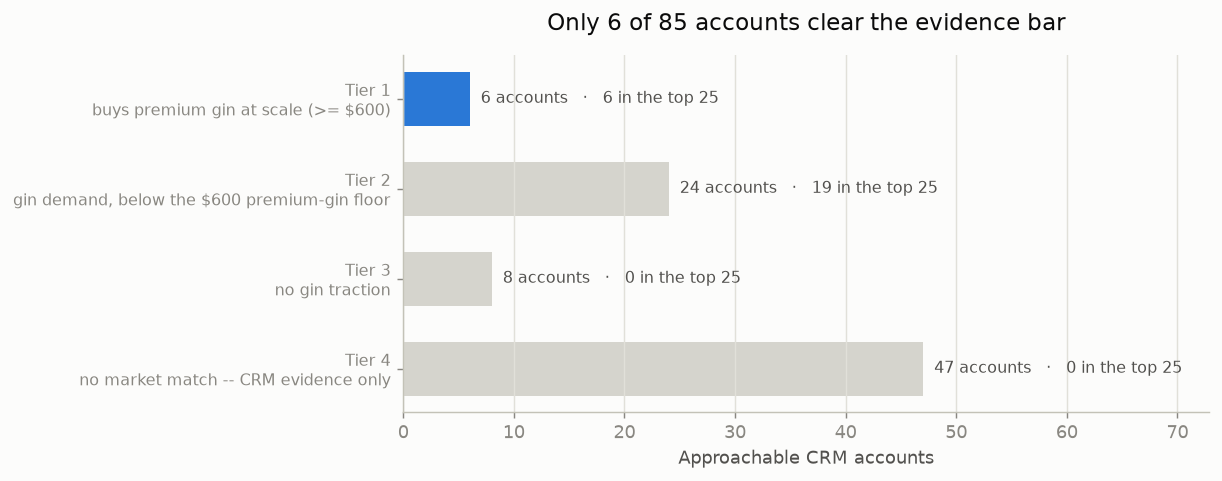

matched to an Iowa store   38 of 85
premium gin in the top 25  $127,481 of $128,199 (99.4% of all the evidence in the book)


In [3]:
tiers = (targets.groupby(["evidence_tier", "evidence_tier_label"])
         .agg(accounts=("account_id", "size"), in_top25=("is_top_target", "sum"))
         .reset_index().sort_values("evidence_tier", ascending=False))

labels = [f"Tier {t}\n{lbl}" for t, lbl in zip(tiers["evidence_tier"], tiers["evidence_tier_label"])]

fig, ax = plt.subplots(figsize=(9.5, 3.8))
# Colour follows the entity (tier 1 = the proven tier), never the rank.
colours = [BLUE if t == 1 else GREY for t in tiers["evidence_tier"]]
bars = ax.barh(labels, tiers["accounts"], color=colours, height=0.6)

for bar, (_, row) in zip(bars, tiers.iterrows()):
    ax.text(bar.get_width() + 1.0, bar.get_y() + bar.get_height() / 2,
            f"{int(row.accounts)} accounts   ·   {int(row.in_top25)} in the top 25",
            va="center", fontsize=9, color=INK2)

ax.set_xlim(0, tiers["accounts"].max() * 1.55)
ax.set_xlabel("Approachable CRM accounts")
ax.set_title("Only 6 of 85 accounts clear the evidence bar", pad=14, fontsize=12.5)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()

n_matched = int(targets["has_market_match"].sum())
prem_top = targets.loc[targets["is_top_target"], "premium_gin_dollars"].fillna(0).sum()
prem_all = targets["premium_gin_dollars"].fillna(0).sum()
print(f"matched to an Iowa store   {n_matched} of {len(targets)}")
print(f"premium gin in the top 25  {usd(prem_top)} of {usd(prem_all)} "
      f"({prem_top / prem_all * 100:.1f}% of all the evidence in the book)")

**The finding: the client's book does not contain 25 strong candidates.**

Six accounts clear the floor. The top 25 holds **99.4%** of all the premium-gin evidence in the
entire approachable universe — the other 60 accounts hold **\$717 between them**. That is not a
ranking artefact; it is the shape of the book.

The honest reading of the deliverable is therefore: **ranks 1–6 are a target list. Ranks 7–25 are
the best of what remains**, and they are there because the brief asks for 25. A rep working this
list top-down will feel the drop-off after #6, and should.

## 3. What "premium" means here — validated on price, not on a label

Iowa's `category_name` classifies gin by **origin** (`IMPORTED…` vs `AMERICAN…`). Thameswood
competes on **price**. Those are different axes, and taking Iowa's wording at face value is a trap:
it puts flavoured gin — which sells at essentially the imported price — in the "not our market"
bucket.

So the tier boundary was set by measuring dollars per bottle across 2021–2026, not by reading
category names.

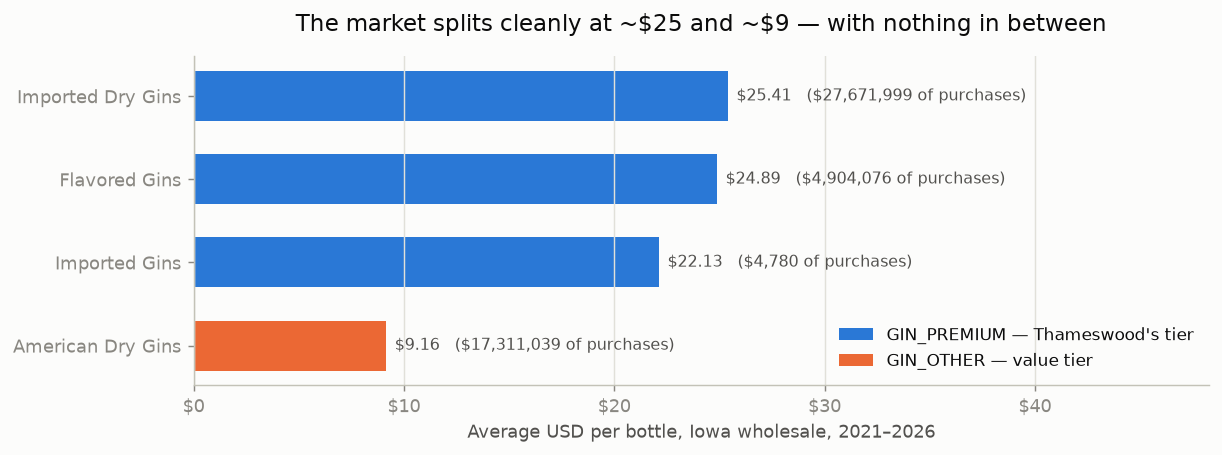

GIN_PREMIUM  $25.33/bottle
GIN_OTHER    $9.16/bottle   ->  2.77x price gap


In [4]:
cats = categories.sort_values("usd_per_bottle")

fig, ax = plt.subplots(figsize=(9.5, 3.6))
colours = [BLUE if g == "GIN_PREMIUM" else ORANGE for g in cats["cat_group"]]
bars = ax.barh(cats["gin_category"].str.title(), cats["usd_per_bottle"],
               color=colours, height=0.6)

for bar, (_, row) in zip(bars, cats.iterrows()):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f"${row.usd_per_bottle:,.2f}   ({usd(row.dollars)} of purchases)",
            va="center", fontsize=9, color=INK2)

ax.set_xlim(0, cats["usd_per_bottle"].max() * 1.9)
ax.set_xlabel("Average USD per bottle, Iowa wholesale, 2021–2026")
ax.set_title("The market splits cleanly at ~$25 and ~$9 — with nothing in between",
             pad=14, fontsize=12.5)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=BLUE, label="GIN_PREMIUM — Thameswood's tier"),
                   Patch(facecolor=ORANGE, label="GIN_OTHER — value tier")],
          loc="lower right", fontsize=9.5)

plt.tight_layout()
plt.show()

prem = cats[cats["cat_group"] == "GIN_PREMIUM"]["dollars"].sum() / cats[cats["cat_group"] == "GIN_PREMIUM"]["bottles"].sum()
other = cats[cats["cat_group"] == "GIN_OTHER"]["dollars"].sum() / cats[cats["cat_group"] == "GIN_OTHER"]["bottles"].sum()
print(f"GIN_PREMIUM  ${prem:.2f}/bottle")
print(f"GIN_OTHER    ${other:.2f}/bottle   ->  {prem / other:.2f}x price gap")

**The split is bimodal, so the boundary is a real feature of the market rather than a judgement
call.** Two consequences worth stating plainly, because both changed the answer:

- **`FLAVORED GIN` belongs in the premium tier** at \$24.89/bottle — 98% of imported dry gin's
  price, and the only gin category in Iowa that is *growing*. It is also where Thameswood's own
  *Elderflower Expression* (£35, 42% ABV) would be shelved. An earlier version classified it as
  value tier on the strength of its name.
- **`AMERICAN SLOE GINS` stays excluded**, now with evidence: a separate validation query against
  the raw table priced it at **\$8.34/bottle** — the *cheapest* gin category in the data, below
  domestic dry gin. It is a ~15–25% ABV liqueur against Thameswood's 41.4–47% range. (It is
  absent from the chart because the extract classifies it as `NON_GIN`, so it never enters the
  warehouse as gin.)

One caveat kept in view: `IMPORTED GINS` shows \$22.13/bottle on **13 order lines ever**, none
since May 2022. It is retained in the premium set for completeness but contributes nothing.

## 4. The market is premiumising — this corrects an earlier finding

Read on origin alone, this data appears to say Thameswood's category is in decline. Read on the
correct price tier, it says something close to the opposite — and far more useful.

2026 is excluded from both charts: the data ends 30 April 2026, so it holds four months against
everyone else's twelve. Plotting it would show a cliff that is a calendar artefact, not a trend.

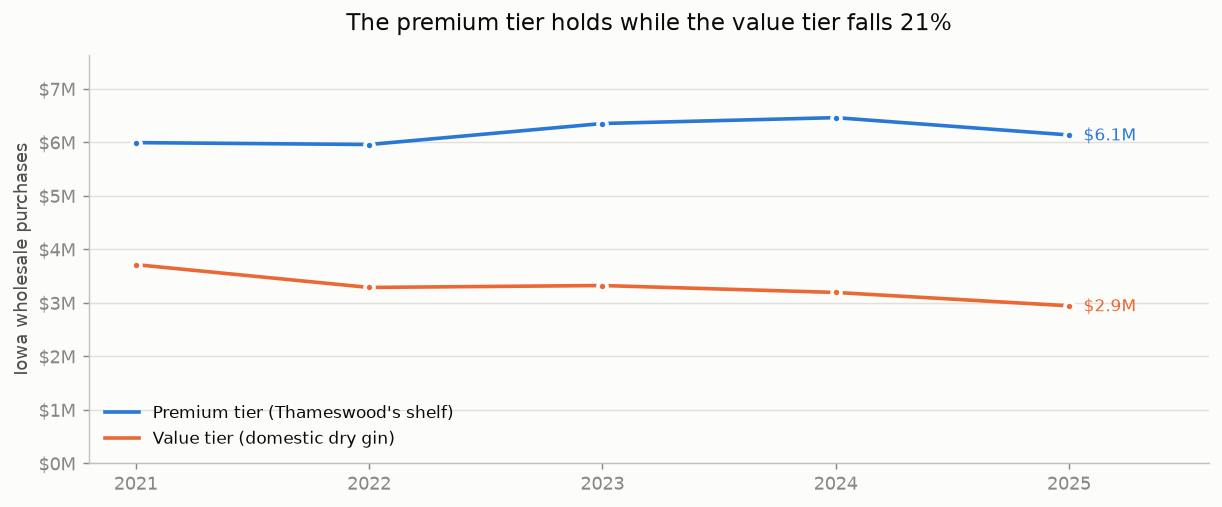

Premium tier (Thameswood's shelf)      $5,993,678 -> $6,136,716  (+2%)
Value tier (domestic dry gin)          $3,712,781 -> $2,943,472  (-21%)


In [5]:
from matplotlib.lines import Line2D

series = {"GIN_PREMIUM": ("Premium tier (Thameswood's shelf)", BLUE),
          "GIN_OTHER":   ("Value tier (domestic dry gin)", ORANGE)}

fig, ax = plt.subplots(figsize=(9.5, 4.0))
for group, (label, colour) in series.items():
    s = trend[trend["cat_group"] == group].sort_values("year")
    ax.plot(s["year"], s["dollars"], color=colour, lw=2, marker="o", markersize=5,
            label=label, markeredgecolor=SURFACE, markeredgewidth=2)
    last = s.iloc[-1]
    ax.annotate(f"${last.dollars / 1e6:.1f}M", xy=(last.year, last.dollars),
                xytext=(8, -3), textcoords="offset points", color=colour, fontsize=9.5)

ax.set_ylim(0, trend["dollars"].max() * 1.18)
ax.set_xlim(2020.8, 2025.6)
ax.set_xticks(range(2021, 2026))
ax.set_ylabel("Iowa wholesale purchases")
ax.set_title("The premium tier holds while the value tier falls 21%", pad=14, fontsize=12.5)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}M"))
ax.legend([Line2D([0], [0], color=c, lw=2) for _, c in series.values()],
          [l for l, _ in series.values()], loc="lower left", fontsize=9.5)

plt.tight_layout()
plt.show()

for group, (label, _) in series.items():
    s = trend[trend["cat_group"] == group].set_index("year")
    chg = (s.dollars.loc[2025] / s.dollars.loc[2021] - 1) * 100
    print(f"{label:<38} {usd(s.dollars.loc[2021])} -> {usd(s.dollars.loc[2025])}  ({chg:+.0f}%)")

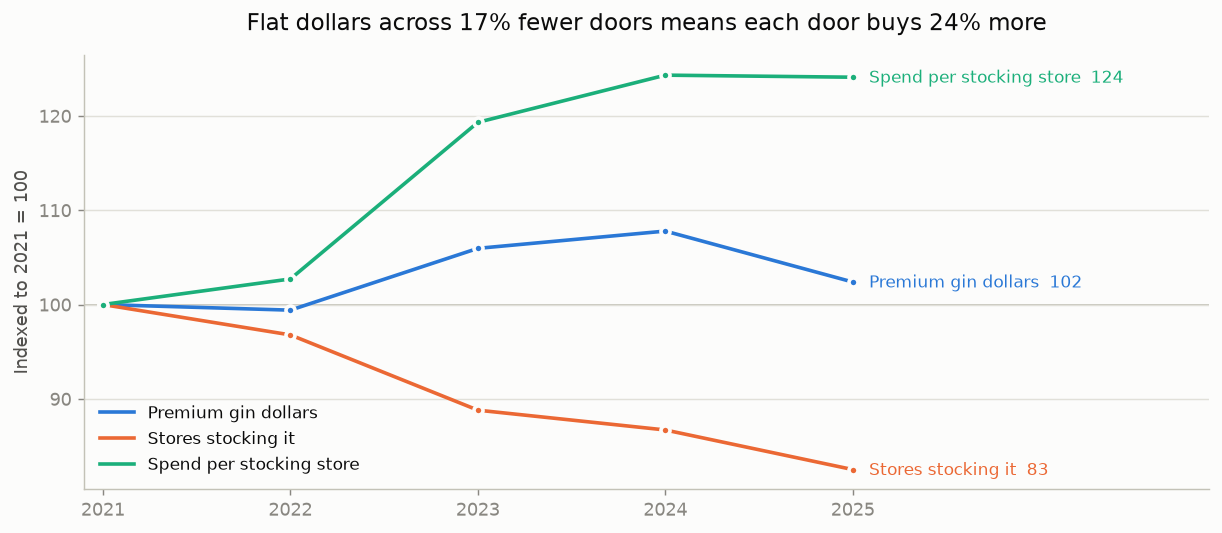

premium dollars     $5,993,678 -> $6,136,716   (+2.4%)
stocking stores     1,429 -> 1,179   (-17.5%)
spend per store     $4,194 -> $5,205   (+24.1%)


In [6]:
# Three measures of different scale on ONE axis, the only legitimate way:
# index every series to 2021 = 100 so they share a unit. Never two y-scales.
p = trend[trend["cat_group"] == "GIN_PREMIUM"].sort_values("year").set_index("year")
p["per_store"] = p["dollars"] / p["stores"]

indexed = {
    "Premium gin dollars":        (p["dollars"] / p["dollars"].iloc[0] * 100, BLUE),
    "Stores stocking it":         (p["stores"] / p["stores"].iloc[0] * 100, ORANGE),
    "Spend per stocking store":   (p["per_store"] / p["per_store"].iloc[0] * 100, AQUA),
}

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.axhline(100, color=AXIS, lw=1, zorder=1)

for label, (s, colour) in indexed.items():
    ax.plot(s.index, s.values, color=colour, lw=2, marker="o", markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
    # Every series direct-laballed: identity is never carried by colour alone,
    # and AQUA is below 3:1 contrast so labels are the required relief.
    ax.annotate(f"{label}  {s.iloc[-1]:.0f}", xy=(s.index[-1], s.iloc[-1]),
                xytext=(9, -3), textcoords="offset points", color=colour, fontsize=9.5)

ax.set_xlim(2020.9, 2026.9)
ax.set_xticks(range(2021, 2026))
ax.set_ylabel("Indexed to 2021 = 100")
ax.set_title("Flat dollars across 17% fewer doors means each door buys 24% more",
             pad=14, fontsize=12.5)
ax.legend([Line2D([0], [0], color=c, lw=2) for _, c in indexed.values()],
          list(indexed.keys()), loc="lower left", fontsize=9.5)

plt.tight_layout()
plt.show()

print(f"premium dollars     {usd(p.dollars.iloc[0])} -> {usd(p.dollars.iloc[-1])}   ({(p.dollars.iloc[-1]/p.dollars.iloc[0]-1)*100:+.1f}%)")
print(f"stocking stores     {p.stores.iloc[0]:,} -> {p.stores.iloc[-1]:,}   ({(p.stores.iloc[-1]/p.stores.iloc[0]-1)*100:+.1f}%)")
print(f"spend per store     {usd(p.per_store.iloc[0])} -> {usd(p.per_store.iloc[-1])}   ({(p.per_store.iloc[-1]/p.per_store.iloc[0]-1)*100:+.1f}%)")

**Why this is the best news in the deck.** Total spend is (stores stocking it) × (average spend per
those stores). Premium dollars held flat while 250 stores stopped stocking the category — so the
money did not leave, it **concentrated into the stores that stayed**.

- *"The category is declining"* would tell a distiller: shrinking pie, bad time to enter.
- *"Flat dollars, 17% fewer doors"* tells them: demand is intact and has consolidated into a
  smaller set of committed retailers. **The fight is for shelf space, not for the consumer.**

It also strengthens the ranking. If the money were spread evenly, ranking by spend would mostly
find *big shops*. In a consolidating category, a store still buying premium gin kept the SKU when
250 of its peers dropped it — so "still buys premium gin" is a **survivorship** signal, not just a
size signal.

**The counterweight, stated honestly:** fewer stocking doors also means fewer available listings.
Distribution is harder to win and each listing matters more. It cuts both ways — just not in the
"category is dying" direction.

## 5. Who does the work — and the volume-versus-fit trade

All 85 accounts carry a named contact, so nothing here needs sourcing before a call. The list
spreads across four reps and all four CRM segments, so no single person absorbs it.

In [7]:
by_owner = (top.groupby("account_owner")
            .agg(accounts=("account_id", "size"),
                 pipeline=("open_pipeline_gbp", "sum"),
                 tier1=("evidence_tier", lambda s: int((s == 1).sum())))
            .sort_values("accounts", ascending=False))
by_owner["pipeline"] = by_owner["pipeline"].map(gbp)
display(by_owner)

by_segment = (top.groupby("crm_segment")
              .agg(accounts=("account_id", "size"))
              .sort_values("accounts", ascending=False))
display(by_segment)

# Previous losses: kept in the universe, demoted within their tier.
lost = targets[targets["target_type"] == "previous_loss"]
print(f"\n{len(lost)} previously-lost accounts kept in the universe, demoted within their tier:")
for _, r in lost.iterrows():
    print(f"  #{r.target_rank:<4} tier {r.evidence_tier}  {r.account_name[:36]:<38} {usd(r.tier_measure)}")
print(f"\n  none reach the top 25; the best sits at #{int(lost.target_rank.min())}")

,accounts,pipeline,tier1
account_owner,,,
Marcus Webb,9,"£137,265",3
Priya Nair,6,"£136,126",2
Sarah Chen,5,"£98,214",0
Tom Holloway,5,"£149,954",1


,accounts
crm_segment,
Premium Off-Trade,8
Independent Specialist,7
Grocery Multiple,6
Wholesale Club,4



8 previously-lost accounts kept in the universe, demoted within their tier:
  #29   tier 2  Super Stop - Altoona                   $1,076
  #30   tier 2  Cvs - Pharmacy #8539 - Iowa City       $427
  #80   tier 4  Transit General Store - Sioux City,    $0
  #81   tier 4  Ross Tobacco Shop - Ottumwa            $0
  #82   tier 4  Casey's #4315                          $0
  #83   tier 4  Bp - Welton                            $0
  #84   tier 4  Oly's C Store                          $0
  #85   tier 4  Mcclure's Bottle Shop, Wines & More    $0

  none reach the top 25; the best sits at #29


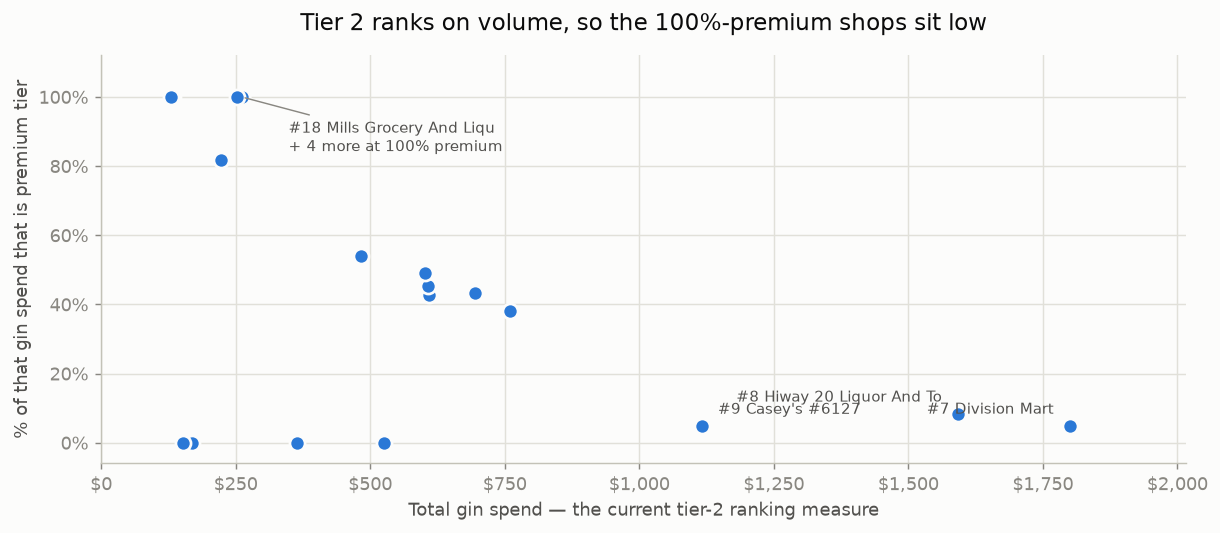

In [8]:
# The volume-versus-fit trade, inside tier 2. Not a ranking change -- a look at
# what the current sort key costs, so the choice is made deliberately.
t2 = targets[(targets["evidence_tier"] == 2) & targets["is_top_target"]].copy()
t2["prem_pct"] = t2["premium_share_of_gin"].fillna(0) * 100

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.scatter(t2["tier_measure"], t2["prem_pct"], s=70, color=BLUE,
           edgecolor=SURFACE, linewidth=1.5, zorder=3)

def name_of(row):
    return f"#{int(row.target_rank)} {row.account_name.split(' - ')[0][:22]}"

# Selective direct labels. Labelling every point stacks six of them on top of
# one another at 100% -- the pure-fit cluster gets ONE annotation naming its
# leader and counting the rest.
xmax = t2["tier_measure"].max()
for _, r in t2.nlargest(3, "tier_measure").iterrows():
    right = r.tier_measure > xmax * 0.66      # flip inward so nothing clips
    ax.annotate(name_of(r), xy=(r.tier_measure, r.prem_pct),
                xytext=(-9, 7) if right else (9, 7), textcoords="offset points",
                fontsize=8.5, color=INK2, ha="right" if right else "left")

pure = t2[t2["prem_pct"] >= 99].sort_values(["tier_measure", "target_rank"],
                                            ascending=[False, True])
if len(pure):
    lead, extra = pure.iloc[0], len(pure) - 1
    txt = name_of(lead) + (f"\n+ {extra} more at 100% premium" if extra else "")
    ax.annotate(txt, xy=(lead.tier_measure, lead.prem_pct), xytext=(26, -30),
                textcoords="offset points", fontsize=8.5, color=INK2,
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))

ax.set_xlim(0, xmax * 1.12)
ax.set_xlabel("Total gin spend — the current tier-2 ranking measure")
ax.set_ylabel("% of that gin spend that is premium tier")
ax.set_title("Tier 2 ranks on volume, so the 100%-premium shops sit low", pad=14, fontsize=12.5)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylim(-6, 112)
ax.grid(axis="x", visible=True)

plt.tight_layout()
plt.show()

**The unresolved trade, put in front of the client rather than hidden in a score.** Inside tier 2
the ranking sorts on *total gin volume*, which produces this:

| | total gin | of which premium | prem % | rank |
|---|---|---|---|---|
| Division Mart | \$1,800 | \$85 | **5%** | **#7** |
| Mills Grocery | \$261 | \$261 | **100%** | **#18** |

Two defensible theories, and V1 picks one:

- **Volume** *(what the model does)* — Division Mart moves 7× more gin. Its customers buy gin
  regularly, just cheap gin. The sales job is *trading them up*, and the prize is bigger.
- **Fit** *(what prem % argues)* — Mills's gin customers buy nothing but premium. There is no
  price objection to overcome. But the store is tiny, so total conversion is worth a few hundred
  dollars.

Which is right depends on whether Thameswood's reps are better at converting volume or slotting
into a premium shelf — a client question, not a data question. This version ranks on volume as the
more defensible default and **shows `prem %` beside it** so a rep can see the trade and choose.
It is listed as a known weakness in section 7 rather than resolved by a weight nobody agreed to.

## 6. The gap that limits everything above

The market data can only score an account we can match to an Iowa store. For most of the book, we
cannot.

In [9]:
def match_state(r):
    if r["has_market_match"]:
        return "Matched to an Iowa store"
    if pd.isna(r["store_number"]) or not str(r["store_number"]).strip():
        return "No store_number on the account"
    return "store_number not found in market data"

targets["match_state"] = targets.apply(match_state, axis=1)
coverage = (targets.groupby("match_state")
            .agg(accounts=("account_id", "size"),
                 in_top25=("is_top_target", "sum"),
                 pipeline_gbp=("open_pipeline_gbp", "sum"))
            .sort_values("accounts", ascending=False))
coverage["pipeline_gbp"] = coverage["pipeline_gbp"].map(gbp)
display(coverage)

unmatched = targets[~targets["has_market_match"]]
print(f"{len(unmatched)} of {len(targets)} accounts ({len(unmatched)/len(targets)*100:.0f}%) "
      f"cannot be scored on market data at all.")
print(f"They carry {gbp(unmatched['open_pipeline_gbp'].sum())} of open pipeline between them — "
      f"real commercial value this analysis is blind to.")

,accounts,in_top25,pipeline_gbp
match_state,,,
No store_number on the account,40,0,"£665,835"
Matched to an Iowa store,38,25,"£703,082"
store_number not found in market data,7,0,"£160,293"


47 of 85 accounts (55%) cannot be scored on market data at all.
They carry £826,129 of open pipeline between them — real commercial value this analysis is blind to.


**This is the highest-value fix available, and it costs the client nothing but data entry.**

47 of 85 approachable accounts cannot be matched to the Iowa market — 40 have no `store_number`
recorded at all. Those accounts hold real open pipeline; the analysis simply cannot see them, so
they land in tier 4 and never reach the top 25 regardless of how good they are.

Populating `store_number` on the CRM would move accounts up the ladder *immediately*, with no
model change — the pipeline already handles them. If the client does one thing after reading this,
it should be that.

## 7. Assumptions and caveats

**Scope decisions**

| Decision | Choice | Why |
|---|---|---|
| Universe | Accounts in Thameswood's CRM | Scope decision: the market data scores accounts, it does not supply them. Iowa stores with no CRM record are out. |
| Already won | Excluded (15) | Already customers; there is nothing to approach. |
| Already lost | **Kept, demoted** (8) | A previous loss is harder work than a live prospect, not worthless. Demoted within its tier, never deleted. `exclude_closed_lost` drops them entirely. |
| Window | Jan 2025 – Apr 2026 (16 months) | The same 16 months for every store, so it is fair to rank on. Not valid for year-on-year comparison. |
| "Premium gin" | Priced, not labelled | `IMPORTED DRY GINS` + `FLAVORED GIN(S)` + `IMPORTED GINS`, all ~\$22–25/bottle. `AMERICAN DRY GINS` (\$9.16) and `AMERICAN SLOE GINS` (\$8.34) are value tier. |
| Materiality floor | \$600 of premium gin | Below it, "this shelf exists" is not a reasonable inference. Sub-floor accounts fall to tier 2, never out. |

**Known weaknesses of V1**

1. **The book does not contain 25 strong candidates.** Six accounts clear the floor; ranks 7–25
   are the best of what remains. Stated plainly rather than dressed up. *(section 2)*
2. **47 accounts cannot be scored at all.** Not a modelling flaw — a CRM data gap. *(section 6)*
3. **Fit is computed but not ranked on.** `premium_share_of_gin` is shown, not scored, so a
   100%-premium shop can sit eleven places below a 5%-premium one. *(section 5)*
4. **No momentum signal.** An account whose gin sales halved ranks the same as one that doubled.
   Fixing this needs the market extract re-run at month grain — calendar years cannot express a
   trailing twelve months.
5. **Recency is ignored.** An account that last bought gin in early 2025 ranks alongside one
   buying monthly.
6. **The \$600 floor is not a natural break.** #6 clears it at \$624; one previous loss misses at
   \$466. A \$450 floor would change tier 1's membership. The value is defensible, not derived.
7. **Store attributes come from a wholesale feed**, so a few matched records look like
   distribution depots rather than retail storefronts and are worth eyeballing.

**What I would ask the client**

- Should tier 2 reward **volume** or **fit**? Section 5 is a real fork and it changes the list.
- Is `store_number` capturable on the other 47 accounts? It is worth more than any model change.
- Should previous losses be revisited after some period, or permanently retired?
- Is there a minimum viable order size below which an account is not worth opening?